In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
from sklearn.tree import plot_tree

In [26]:
df = sns.load_dataset('diamonds')

In [27]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [28]:
df.isnull().sum().sort_values(ascending = False)

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [29]:
# 3. ENCODE INDIVIDUALLY
labelencoder = LabelEncoder()
le_cut = LabelEncoder()
le_clarity = LabelEncoder()
le_color = LabelEncoder()
df['cut'] = le_cut.fit_transform(df['cut'])
df['clarity'] = le_clarity.fit_transform(df['clarity'])
df['color'] = le_color.fit_transform(df['color'])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [30]:
X = df.drop('price',axis=1)
y = df.price

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2, random_state=0)
modelregresssor = DecisionTreeRegressor(max_depth=2,random_state=0)


In [32]:
modelregresssor.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [33]:
regressor_train_score = modelregresssor.score(X_train,y_train)
regressor_test_score = modelregresssor.score(X_test,y_test)
print("The train score of Decision Tree Regressor model is : ",regressor_train_score)
print("The test score of Decision Tree Regressor model is ",regressor_test_score)

The train score of Decision Tree Regressor model is :  0.8269317633304415
The test score of Decision Tree Regressor model is  0.8325989636386455


In [34]:
y_pred = modelregresssor.predict(X_test)

In [35]:

print("R 2 score : ", r2_score(y_test,y_pred))
print("Mean absolute score : ",mean_absolute_error(y_test,y_pred))
print("The mean sqaured absolut error is : ",np.sqrt(mean_squared_error(y_test,y_pred)))

R 2 score :  0.8325989636386455
Mean absolute score :  1032.2392487757754
The mean sqaured absolut error is :  1628.9836455684556


[Text(0.5, 0.8333333333333334, 'x[0] <= 0.995\nsquared_error = 15931243.845\nsamples = 43152\nvalue = 3933.697'),
 Text(0.25, 0.5, 'x[7] <= 5.535\nsquared_error = 1244990.344\nsamples = 27901\nvalue = 1633.659'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 274364.974\nsamples = 19967\nvalue = 1059.895'),
 Text(0.375, 0.16666666666666666, 'squared_error = 774209.979\nsamples = 7934\nvalue = 3077.613'),
 Text(0.75, 0.5, 'x[7] <= 7.195\nsquared_error = 15415240.345\nsamples = 15251\nvalue = 8141.51'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 4731968.702\nsamples = 10316\nvalue = 6139.793'),
 Text(0.875, 0.16666666666666666, 'squared_error = 11862724.366\nsamples = 4935\nvalue = 12325.849')]

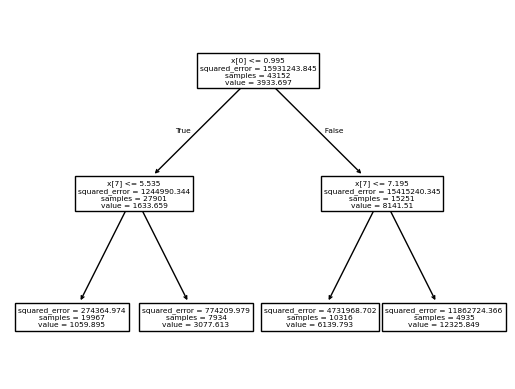

In [36]:
plot_tree(modelregresssor)


In [37]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [38]:
# df['cut'] = labelencoder.inverse_transform(df['cut'])
# df['clarity'] = labelencoder.inverse_transform(df['clarity'])
# df['color'] = labelencoder.inverse_transform(df['color'])
# df.head()


# 4. DECODE INDIVIDUALLY (Run this cell ONLY ONCE)
df['cut'] = le_cut.inverse_transform(df['cut'])
df['clarity'] = le_clarity.inverse_transform(df['clarity'])
df['color'] = le_color.inverse_transform(df['color'])

# print("\nDecoded Data:")
# print(df[['cut', 'clarity', 'color']].head())
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Decision Tree Classifier Algorithm

In [39]:
# 3. ENCODE INDIVIDUALLY
labelencoder = LabelEncoder()
le_cut = LabelEncoder()
le_clarity = LabelEncoder()
le_color = LabelEncoder()
df['cut'] = le_cut.fit_transform(df['cut'])
df['clarity'] = le_clarity.fit_transform(df['clarity'])
df['color'] = le_color.fit_transform(df['color'])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [40]:
X = df.drop('color',axis=1)
y = df.color

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2, random_state=0)
modelclassifier = DecisionTreeClassifier(max_depth=2,random_state=0)

In [42]:
modelclassifier.fit(X_train,y_train)
print("The model classifier train score is : ",modelclassifier.score(X_test,y_test))
print("The model classifier test score is : ",modelclassifier.score(X_test,y_test))
y_pred = modelclassifier.predict(X_test)


The model classifier train score is :  0.22098628105302187
The model classifier test score is :  0.22098628105302187


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("The Accuracy score of this model is : ",accuracy_score(y_test,y_pred))
print("The Recall score of this model is : ", recall_score(y_test,y_pred,average="micro"))
print("The Precision score of this model is : ",precision_score(y_test,y_pred,average="micro"))
print("The f1 score of this model is : ",f1_score(y_test,y_pred,average="micro"))

The Accuracy score of this model is :  0.22098628105302187
The Recall score of this model is :  0.22098628105302187
The Precision score of this model is :  0.22098628105302187
The f1 score of this model is :  0.22098628105302187


[Text(0.5, 0.8333333333333334, 'x[8] <= 4.105\ngini = 0.84\nsamples = 43152\nvalue = [5450.0, 7851.0, 7745.0, 8914.0, 6623.0, 4324.0, 2245.0]'),
 Text(0.25, 0.5, 'x[5] <= 5914.5\ngini = 0.829\nsamples = 34086\nvalue = [4946, 7107, 6644, 7132, 4564, 2559, 1134]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.832\nsamples = 31938\nvalue = [4644, 6686, 6070, 6373, 4483, 2548, 1134]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.744\nsamples = 2148\nvalue = [302, 421, 574, 759, 81, 11, 0]'),
 Text(0.75, 0.5, 'x[7] <= 7.935\ngini = 0.832\nsamples = 9066\nvalue = [504, 744, 1101, 1782, 2059, 1765, 1111]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.834\nsamples = 7453\nvalue = [464, 670, 997, 1592, 1649, 1302, 779]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.79\nsamples = 1613\nvalue = [40, 74, 104, 190, 410, 463, 332]')]

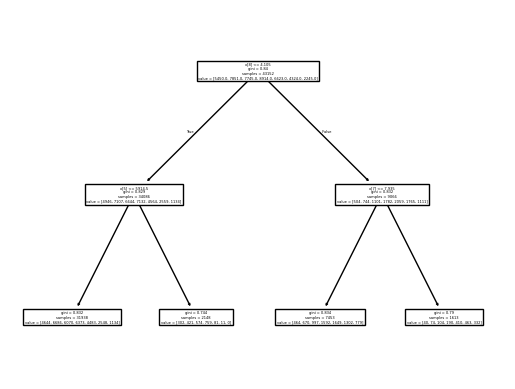

In [44]:
plot_tree(modelclassifier)

In [45]:
# 4. DECODE INDIVIDUALLY (Run this cell ONLY ONCE)
df['cut'] = le_cut.inverse_transform(df['cut'])
df['clarity'] = le_clarity.inverse_transform(df['clarity'])
df['color'] = le_color.inverse_transform(df['color'])

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
